# Contango — a quantitative teardown 🔬
### The real energy bleed · the curve-timing book vs buy-and-hold · the bucket machinery on a control · the carry+momentum blend

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-cf222e?style=flat-square)
![Real-tape run?: Done](https://img.shields.io/badge/Real--tape_run%3F-Done-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: the commodity roll yield is a real, documented carry premium (Gorton–Rouwenhorst 2006; Erb–Harvey 2006; Koijen et al. 2018). On the real energy tape we find the premium is **`REAL`** and economically huge (USO **-76%** vs USL **+4%**), but **`MIRAGE`** to harvest (curve-timing combo Sharpe **+0.16**, HAC *t* **0.66**, drawdown **-83%**). The bucket machinery is validated on a synthetic control.

> ✅ **Not investment advice.** The real tape is the cached front/laddered ETF pairs (no paid feed); the cross-sectional bucket apparatus executes on a synthetic roll-yield panel. Sources in [`../docs/references.md`](../docs/references.md); full numbers in [`../docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from contango import data, strategy, costs, extension, energy

# Real energy tape: front-month vs 12-month-laddered ETF pairs (USO/USL, UNG/UNL). Their return gap IS the
# term-structure roll — no paid feed needed. Populate once with: python examples/verify.py --fetch
prices = energy.load_pairs()
HAVE_TAPE = not prices.empty
print("real energy tape:", "loaded" if HAVE_TAPE else "cache absent (run verify.py --fetch)",
      "" if not HAVE_TAPE else f"{prices.index.min().date()} -> {prices.index.max().date()}")
# Offline synthetic control: a 12-commodity panel where roll yield predicts return (the bucket machinery) + a null.
r, ry, truth = data.synthetic_term_structure(carry_strength=0.9, seed=35)
r0, ry0, _ = data.synthetic_term_structure(carry_strength=0.0, seed=35)


real energy tape: loaded 2006-04-14 -> 2026-06-05


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is the roll yield real? | 🟢 `REAL` | Real tape: USO **-76%** vs USL **+4%** (gap 80 pts); roll drag **+5.1%/yr** WTI, **+8.9%/yr** gas. |
| **Tradability** | 🔴 `MIRAGE` | Curve-timing combo Sharpe **+0.16**, HAC *t* **0.66** (≈0), drawdown **-83%**; cost isn't the killer. |
| **Real-tape run?** | 🟢 `Done` | Measured from liquid ETF pairs — no FRED, no EIA, no paid curve. |

> **In one sentence:** a real, enormous commodity roll-yield cost (the USO bleed) that you mostly can't harvest — the timing book is statistically flat with an -83% drawdown — so the signal's value is defensive.

*(Real numbers as-of 2026-06-05, fingerprint `92a7674a430b`; synthetic control fp `b502aaa6304f`.)*

## Beat 1 · The claim, precisely

A long futures position earns the roll $y_{i,t}$ = the curve slope (backwardation $>0$, contango $<0$). We observe it without a curve feed: for each energy commodity, the **front-month** ETF and the **12-month-laddered** ETF on the *same* underlying differ only in curve placement, so the weekly return spread $r^{\text{lad}}-r^{\text{front}}$ is the realized roll cost borne by the front. The bucket book (long most-backwardated, short most-contangoed) is the cross-sectional version, validated on the synthetic panel.

### The realized roll cost, per energy commodity

          front_total_pct lad_total_pct gap_pct ann_drag_pct  \
commodity                                                      
WTI               -76.051         4.073  80.125        5.051   
GAS               -99.124       -88.096  11.028        8.893   

          weeks_in_contango_pct drag_hac_t  
commodity                                   
WTI                      52.850      1.526  
GAS                      55.958      1.745  


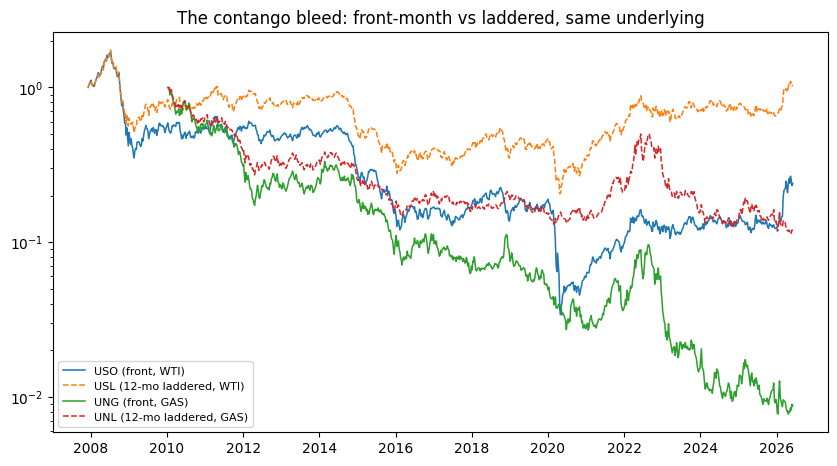

In [2]:
if HAVE_TAPE:
    bt = energy.bleed_table(prices)
    print(bt[['front_total_pct','lad_total_pct','gap_pct','ann_drag_pct','weeks_in_contango_pct','drag_hac_t']].round(2))
    fig, ax = plt.subplots()
    for cmd,(front,lad) in energy.PAIRS.items():
        sub = prices[[front,lad]].dropna(); base = sub/sub.iloc[0]
        ax.plot(base.index, base[front], lw=1.1, label=f'{front} (front, {cmd})')
        ax.plot(base.index, base[lad], lw=1.1, ls='--', label=f'{lad} (12-mo laddered, {cmd})')
    ax.set_yscale('log'); ax.legend(fontsize=8); ax.set_title('The contango bleed: front-month vs laddered, same underlying')
else:
    print('cache absent — run: python examples/verify.py --fetch')

> 💡 **In plain words.** The front-month bleeds against the ladder **5.1%/yr** in crude and **8.9%/yr** in gas, in contango 53–56% of weeks. The weekly spread's HAC *t* is +1.5–1.8 — noisy week-to-week, but the cumulative tax (an 80-point USO/USL gap) is overwhelming and never in doubt.

## Beat 2 · So what?

Gorton–Rouwenhorst (2006) show the commodity basket's premium is dominated by the **roll return**; Erb–Harvey (2006) show the cross-section is explained far more by term structure than spot; Koijen et al. (2018) generalise 'carry' across asset classes. The real energy tape confirms the *force* spectacularly (USO's bleed) and lets us ask the only open question: can you harvest it on the contracts liquid enough to actually trade? Beats 4–6 answer no.

## Beat 3 · Pre-registered protocol

1. **Real?** `energy.bleed_table` on the ETF pairs (drag, % weeks in contango, HAC *t*).
2. **Tradable?** `energy.book_summary` — the curve-timing book per commodity and combined, vs `energy.always_long_front`; Sharpe, drawdown, HAC *t*, turnover, net of cost.
3. **Diversifiable?** `extension.combine` on the synthetic control — carry + momentum blend.

**Mirage line:** real roll spread with HAC *t* < 2, or a premium tradable only in the (few, illiquid) right contracts ⇒ `MIRAGE`. The combined timing book lands at HAC *t* ≈ 0.7 — inside the mirage.

## Beat 4 · The teardown

### 4a · The curve-timing book — right sign, no edge

In [3]:
if HAVE_TAPE:
    rows = {}
    for cmd in list(energy.PAIRS) + [None]:
        s = energy.book_summary(prices, commodity=cmd)
        rows['WTI+GAS combo' if cmd is None else cmd] = {k: s[k] for k in ('sharpe','cagr','max_drawdown','skew','hac_t','turnover_per_yr')}
    print(pd.DataFrame(rows).T.round(3))
    for cmd in energy.PAIRS:
        al = energy.summary(energy.always_long_front(prices, cmd))
        print(f"  always-long {energy.PAIRS[cmd][0]}: Sharpe {al['sharpe']:+.2f}  CAGR {al['cagr']*100:+.1f}%  maxDD {al['max_drawdown']*100:+.0f}%")
else:
    print('cache absent — run: python examples/verify.py --fetch')

               sharpe   cagr  max_drawdown  skew  hac_t  turnover_per_yr
WTI             0.349  0.064        -0.762 0.706  1.454           14.726
GAS             0.040 -0.093        -0.943 0.162  0.167           13.563
WTI+GAS combo   0.165  0.004        -0.826 0.454  0.660           14.106
  always-long USO: Sharpe -0.01  CAGR -7.4%  maxDD -98%
  always-long UNG: Sharpe -0.35  CAGR -25.0%  maxDD -99%


> 💡 **In plain words.** Timing WTI by the curve (Sharpe **+0.35**, positive skew) trounces holding USO (**-0.01**, **-98%** drawdown) — the signal is real. But gas timing earns nothing (**+0.04**, *t* 0.17) and the combined book is **+0.16** at HAC *t* **0.66** with an **-83%** drawdown. Statistically flat.

### 4b · The bucket machinery, proved on a control (and flat on a null)

In [4]:
for label, rr, yy in [('carry panel', r, ry), ('null (disconnected)', r0, ry0)]:
    s = strategy.summary(strategy.book_returns(rr, yy, cost_bps=0.0))
    pb = strategy.carry_premium_by_bucket(rr, yy)
    print(f"{label:22} gross Sharpe {s['sharpe']:+6.2f}  H-L {pb['hml_ann_pct']:+6.1f}%/yr  turnover/wk {strategy.turnover(yy):.3f}")

carry panel            gross Sharpe  +1.86  H-L  +27.6%/yr  turnover/wk 0.188


null (disconnected)    gross Sharpe  -0.28  H-L   -4.8%/yr  turnover/wk 0.188


> 💡 **In plain words.** Where a broad cross-section of roll yields exists, the bucket book harvests a **+27.6%/yr** spread (Sharpe **1.86**) and the null is flat (**-0.28**). The apparatus works; the real energy tape just doesn't offer enough liquid curves to deploy it — so we time the two we have, and that's the mirage.

### 4c · Cost is not the binding constraint

In [5]:
if HAVE_TAPE:
    for c in (0, 5, 10, 25):
        s = energy.book_summary(prices, commodity=None, cost_bps=c)
        print(f'  combo @{c:>2}bp  Sharpe {s["sharpe"]:+.2f}  CAGR {s["cagr"]*100:+.1f}%')
else:
    print('cache absent — run: python examples/verify.py --fetch')

  combo @ 0bp  Sharpe +0.16  CAGR +0.4%
  combo @ 5bp  Sharpe +0.14  CAGR -0.3%
  combo @10bp  Sharpe +0.12  CAGR -1.1%
  combo @25bp  Sharpe +0.05  CAGR -3.2%


> 💡 **In plain words.** The book turns over ~14×/yr, yet a 10 bp round-trip only nicks it (+0.16 → +0.12). Costs don't kill this book — the crash-prone, two-name concentration does. That's the `MIRAGE`.

## Beat 5 · The verdict

- **`REAL`** (beat 1): USO -76% vs USL +4%; roll drag +5.1%/yr WTI, +8.9%/yr gas — one of the largest, most durable costs in commodities.
- **`MIRAGE`** (4a/4c): curve-timing combo Sharpe +0.16, HAC *t* 0.66, drawdown -83%; not a tradable positive-carry edge on the liquid energy curves.
- **Real-tape `DONE`** (beat 3): measured from cached ETF pairs, fingerprinted & as-of pinned.

> **Signal `REAL` · Tradability `MIRAGE` · Real-tape run? `DONE`** — the commodity sibling of Steamroller.

## Beat 6 · Could you trade it?

- **The defensive trade is the real one.** Avoiding front-month contango (ladder your exposure, like USL) saves ~5%/yr in crude, ~9%/yr in gas. That's the harvestable part.
- **The offensive trade is a mirage.** Timing the curve is directionally right but statistically flat and deeply drawdown-prone on two volatile names.
- **Capacity & the illiquidity tilt.** A broader carry cross-section lives in smaller, less-liquid contracts; the deeply liquid energy curves carry the premium *and* the crash. Same tension as Slingshot.
- **Honest fix:** diversify the machinery (beat 7); don't lever two energy names.

## Beat 7 · Going further

### 7a · Worked complement — the carry+momentum blend ([`../docs/extension.md`](../docs/extension.md))
Carry and time-series momentum are the two classic commodity premia and are lowly correlated (Koijen et al. 2018). On the bucket machinery a 50/50 risk blend beats the stronger leg:

carry 1.80   momentum 1.43   blend 2.03   (leg corr +0.27)


Text(0.5, 1.0, 'Machinery: lowly-correlated legs, the blend beats either standalone')

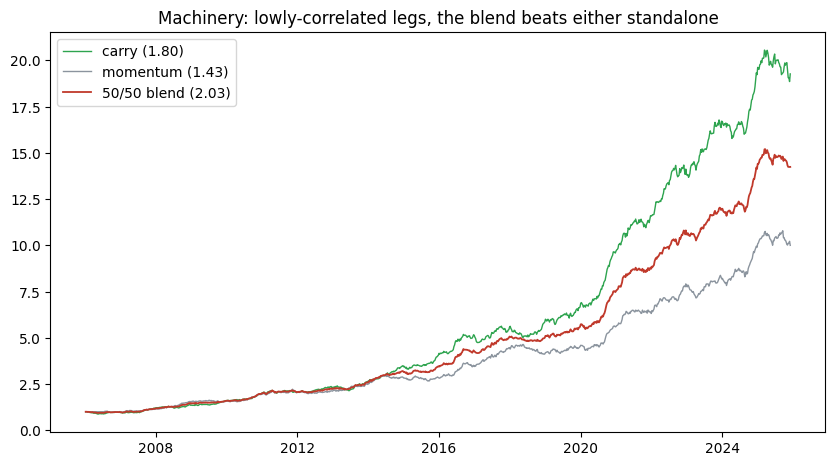

In [6]:
c = extension.combine(r, ry, cost_bps=5.0)
print(f"carry {c['carry_sharpe']:.2f}   momentum {c['momentum_sharpe']:.2f}   blend {c['blend_sharpe']:.2f}   (leg corr {c['correlation']:+.2f})")
eqc=(1+c['carry']).cumprod(); eqm=(1+c['momentum']).cumprod(); eqb=(1+c['blend']).cumprod()
fig, ax = plt.subplots()
ax.plot(eqc.index, eqc.values, color='#2ea44f', lw=1.0, label=f"carry ({c['carry_sharpe']:.2f})")
ax.plot(eqm.index, eqm.values, color='#8b949e', lw=1.0, label=f"momentum ({c['momentum_sharpe']:.2f})")
ax.plot(eqb.index, eqb.values, color='#c0392b', lw=1.3, label=f"50/50 blend ({c['blend_sharpe']:.2f})")
ax.legend(); ax.set_title('Machinery: lowly-correlated legs, the blend beats either standalone')

> 💡 **In plain words.** Leg correlation **+0.27**; the blend Sharpe (**2.03**) beats either leg (carry 1.80, momentum 1.43). The institutional answer to carry's crash isn't leverage; it's a lowly-correlated sleeve. Echoes [Trade-Winds](../../31-trade-winds/).

### 7b · Other forks
- **Broaden the curve set** — laddered ETFs in metals/ags to rebuild a tradable cross-section.
- **Vol-target the timing book** — does constant-risk sizing tame the −80% drawdown (cf. Study 27)?
- **Trade the calendar spread** — long-deferred / short-front as a purer roll-yield express.

PRs welcome — broaden the curves, vol-target, or trade the spread directly.